<h1> Regularization </h1>

Regularization implies:

It is not enough to simply minimize the training error; we must also prevent the model from becoming unnecessarily complex.

This means we modify the cost function.

Previously:

$$ J(w)=MSE $$

Now, we add a penalty term:

$$ J(w)=MSE+\lambda Penalty $$

The concept of λ (Lambda)

The parameter:

$$ \lambda $$

represents the strength of the penalty.

If:

$$ \lambda=0 $$

then:

there is no regularization.

The model:

is simply standard Linear Regression.

If:

$$ \lambda $$

increases:

the model is forced:

to keep the weights smaller.

Two main types of regularization:
### 1) Ridge Regression

Or:

L2 Regularization

Penalty:

$$ \lambda \sum w_i^2 $$

Meaning:

The sum of the squared weights.

For example:

Model:

$$ y=5x_1+8x_2-2x_3 $$

Penalty:

$$ 5^2+8^2+(-2)^2 $$

is the result.

Goal:

Reduces large weights.

But:

Retains all features.

### 2) Lasso Regression

Or:

L1 Regularization

Penalty:

$$ \lambda \sum |w_i| $$

Meaning:

The sum of the absolute values ​​of the weights.

Key difference:

Ridge:

Retains features
but shrinks weights

Lasso:

Sets some weights to zero

Therefore:

Lasso can perform feature selection.

In [211]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

from src.linear_regression import LinearRegressionGD
from src.regularization import (
    RidgeRegressionGD,
    LassoRegressionGD
)

<h3> Step 1: Data generation </h3>

We generate synthetic data, just as before.

Objective:

To intentionally induce overfitting.

Why?

Because if we don't observe overfitting, the effect of regularization won't be visible either.

In [212]:
np.random.seed(42)

X = np.linspace(
    -3,
    3,
    20
)

noise = np.random.normal(
    0,
    10,
    size=X.shape
)

y = (
    2 * X**2
    + 3 * X
    + 5
    + noise
)

X = X.reshape(
    -1,
    1
)

Here, we want to construct a high-degree polynomial:

For example:

degree = 15

This means the model includes:

$$ x, x^2, ..., x^{15} $$

Without regularization:

The weights become large.

Also:

$$ Ridge(\lambda=0)=LinearRegression $$

<h3> Step 2: Train/Test Split </h3>

In [213]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

<h3> Step 3: High-degree polynomial

In [214]:
degree = 30

poly = PolynomialFeatures(
    degree=degree
)

X_train_poly = poly.fit_transform(
    X_train
)

X_test_poly = poly.transform(
    X_test
)

<h3> Step 4: Scaling

In [215]:
scaler = StandardScaler()

X_train_poly = scaler.fit_transform(
    X_train_poly
)

X_test_poly = scaler.transform(
    X_test_poly
)

<h3> Step 5: Model Without Regularization

The same Linear Regression as before.

In [216]:
linear_model = LinearRegressionGD(
    learning_rate=0.001,
    epochs=10000
)

linear_model.fit(
    X_train_poly,
    y_train
)

In [217]:
y_train_pred_linear = linear_model.predict(
    X_train_poly
)

y_test_pred_linear = linear_model.predict(
    X_test_poly
)

In [218]:
linear_train_mse = mean_squared_error(
    y_train,
    y_train_pred_linear
)

linear_test_mse = mean_squared_error(
    y_test,
    y_test_pred_linear
)

print(
    "Linear Regression"
)

print(
    "Train MSE:",
    linear_train_mse
)

print(
    "Test MSE:",
    linear_test_mse
)

Linear Regression
Train MSE: 35.11170461920282
Test MSE: 131.64410835690958


<h3> Step 6: Ridge Regression (L2)

In [219]:
ridge_model = RidgeRegressionGD(
    learning_rate=0.0001,
    epochs=10000,
    lambda_=1
)

In [220]:
ridge_model.fit(
    X_train_poly,
    y_train
)

In [221]:
y_train_pred_ridge = ridge_model.predict(
    X_train_poly
)

y_test_pred_ridge = ridge_model.predict(
    X_test_poly
)

In [222]:
ridge_train_mse = mean_squared_error(
    y_train,
    y_train_pred_ridge
)

ridge_test_mse = mean_squared_error(
    y_test,
    y_test_pred_ridge
)

print(
    "Ridge Regression"
)
print(
    "Train MSE:",
    ridge_train_mse
)
print(
    "Test MSE:",
    ridge_test_mse
)

Ridge Regression
Train MSE: 53.944683637797255
Test MSE: 81.39108472679388


<h3> Step 7: Analyzing the Effect of λ in Ridge Regression

In [223]:
lambda_values = [
    0,
    0.001,
    0.01,
    0.1,
    1,
    10,
    100
]

train_errors = []
test_errors = []

In [224]:
for lambda_value in lambda_values:

    print(
        f"Lambda: {lambda_value}"
    )

    ridge_model = RidgeRegressionGD(
        learning_rate=0.0001,
        epochs=10000,
        lambda_=lambda_value
    )

    ridge_model.fit(
        X_train_poly,
        y_train
    )

    # Prediction on Train
    y_train_pred = ridge_model.predict(
        X_train_poly
    )

    # Prediction on Test
    y_test_pred = ridge_model.predict(
        X_test_poly
    )

    # Calculate MSE
    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    train_errors.append(
        train_mse
    )

    test_errors.append(
        test_mse
    )

    print(
        "Train MSE:",
        train_mse
    )
    print(
        "Test MSE:",
        test_mse
    )
    print("----------------")

Lambda: 0
Train MSE: 45.65768203408665
Test MSE: 122.98771482290526
----------------
Lambda: 0.001
Train MSE: 45.66560019871643
Test MSE: 122.8973501314922
----------------
Lambda: 0.01
Train MSE: 45.7372328629506
Test MSE: 122.09160030675184
----------------
Lambda: 0.1
Train MSE: 46.48397026365547
Test MSE: 114.73308156828432
----------------
Lambda: 1
Train MSE: 53.944683637797255
Test MSE: 81.39108472679388
----------------
Lambda: 10
Train MSE: 70.3416409782286
Test MSE: 84.3938595274323
----------------
Lambda: 100
Train MSE: 78.91074169332748
Test MSE: 94.35833165616953
----------------


In [225]:
results_lambda = pd.DataFrame(
    {
        "Lambda": lambda_values,
        "Train MSE": train_errors,
        "Test MSE": test_errors
    }
)

results_lambda

,Lambda,Train MSE,Test MSE
0,0.000,45.657682,122.987715
1,0.001,45.665600,122.897350
2,0.010,45.737233,122.091600
3,0.100,46.483970,114.733082
4,1.000,53.944684,81.391085
5,10.000,70.341641,84.393860
6,100.000,78.910742,94.358332


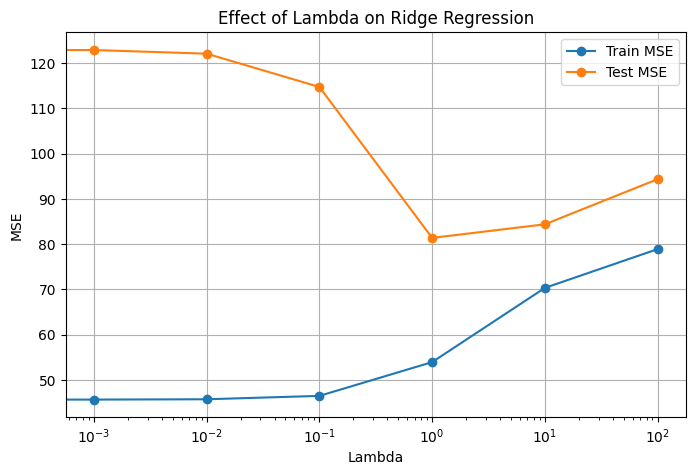

In [226]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    lambda_values,
    train_errors,
    marker="o",
    label="Train MSE"
)

plt.plot(
    lambda_values,
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xscale(
    "log"
)

plt.xlabel(
    "Lambda"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Effect of Lambda on Ridge Regression"
)

plt.legend()
plt.grid()
plt.show()

We deliberately allow the model's performance on the training set to degrade slightly so that it performs better on unseen data.

### Effect of Regularization Strength (Lambda)

The regularization parameter controls the trade-off between fitting the training data and keeping the model complexity low.

When lambda is close to zero, the Ridge model behaves similarly to ordinary linear regression and suffers from high variance and overfitting.

Increasing lambda reduces the magnitude of model coefficients, which slightly increases training error but improves generalization performance.

In this experiment, lambda=1 achieved the best balance between bias and variance, reducing test error significantly compared to the unregularized model.

However, very large lambda values increase bias and lead to underfitting because the model becomes overly constrained.

<h3> Step 8: Lasso Regression (L1)

|                   | Ridge      | Lasso |
| ----------------- | ---------- | ----- |
| Penalty           | L2         | L1    |
| Formula           | $w^2$      | $w$   |
| Weight losses       | yes         | yes  | 
| Zeroing out the weights | usually no | yes | 
| Feature Selection | no          | yes  | 


Ridge gradually shrinks the weights.</br>
Lasso, however, exerts a constant pressure toward zero; for this reason, some weights reach zero.

In [227]:
lasso_model = LassoRegressionGD(
    learning_rate=0.0001,
    epochs=10000,
    lambda_=1
)

In [228]:
lasso_model.fit(
    X_train_poly,
    y_train
)

y_train_pred_lasso = lasso_model.predict(
    X_train_poly
)

y_test_pred_lasso = lasso_model.predict(
    X_test_poly
)

In [229]:
lasso_train_mse = mean_squared_error(
    y_train,
    y_train_pred_lasso
)

lasso_test_mse = mean_squared_error(
    y_test,
    y_test_pred_lasso
)

print(
    "Lasso Regression (lambda = 1)"
)
print(
    "Train MSE:",
    lasso_train_mse
)
print(
    "Test MSE:",
    lasso_test_mse
)

Lasso Regression (lambda = 1)
Train MSE: 49.60261208907953
Test MSE: 102.83344427294418


<h3> Step 9: Analyzing the Effect of λ in Lasso Regression

In [230]:
lambda_values = [
    0,
    0.001,
    0.01,
    0.1,
    1,
    10,
    50,
    100,
    500
]

train_errors = []
test_errors = []

In [231]:

for lambda_value in lambda_values:

    print(
        f"Lambda: {lambda_value}"
    )

    lasso_model = LassoRegressionGD(
        learning_rate=0.0001,
        epochs=10000,
        lambda_=lambda_value
    )

    lasso_model.fit(
        X_train_poly,
        y_train
    )
    
    zero_weights = np.sum(
        np.isclose(
            lasso_model.weights,
            0
        )
    )

    # Prediction on Train
    y_train_pred = lasso_model.predict(
        X_train_poly
    )

    # Prediction on Test
    y_test_pred = lasso_model.predict(
        X_test_poly
    )

    # Calculate MSE
    train_mse = mean_squared_error(
        y_train,
        y_train_pred
    )

    test_mse = mean_squared_error(
        y_test,
        y_test_pred
    )

    train_errors.append(
        train_mse
    )

    test_errors.append(
        test_mse
    )

    print(
        "Train MSE:",
        train_mse
    )
    print(
        "Test MSE:",
        test_mse
    )
    print(
        "Zero weights:",
        zero_weights
    )
    print("----------------")

Lambda: 0
Train MSE: 45.65768203408665
Test MSE: 122.98771482290526
Zero weights: 1
----------------
Lambda: 0.001
Train MSE: 45.66206857738262
Test MSE: 122.96986936163604
Zero weights: 1
----------------
Lambda: 0.01
Train MSE: 45.70182730150395
Test MSE: 122.80799421867351
Zero weights: 1
----------------
Lambda: 0.1
Train MSE: 46.12874817605689
Test MSE: 121.43335988139806
Zero weights: 1
----------------
Lambda: 1
Train MSE: 49.60261208907953
Test MSE: 102.83344427294418
Zero weights: 1
----------------
Lambda: 10
Train MSE: 82.47130692051678
Test MSE: 95.9062658653399
Zero weights: 1
----------------
Lambda: 50
Train MSE: 82.2583956266154
Test MSE: 95.96851132689602
Zero weights: 1
----------------
Lambda: 100
Train MSE: 82.29114653218963
Test MSE: 96.16587373275213
Zero weights: 1
----------------
Lambda: 500
Train MSE: 82.77724203183357
Test MSE: 102.69491948539205
Zero weights: 1
----------------


In [232]:
results_lambda = pd.DataFrame(
    {
        "Lambda": lambda_values,
        "Train MSE": train_errors,
        "Test MSE": test_errors
    }
)

results_lambda

,Lambda,Train MSE,Test MSE
0,0.000,45.657682,122.987715
1,0.001,45.662069,122.969869
2,0.010,45.701827,122.807994
3,0.100,46.128748,121.433360
4,1.000,49.602612,102.833444
5,10.000,82.471307,95.906266
6,50.000,82.258396,95.968511
7,100.000,82.291147,96.165874
8,500.000,82.777242,102.694919


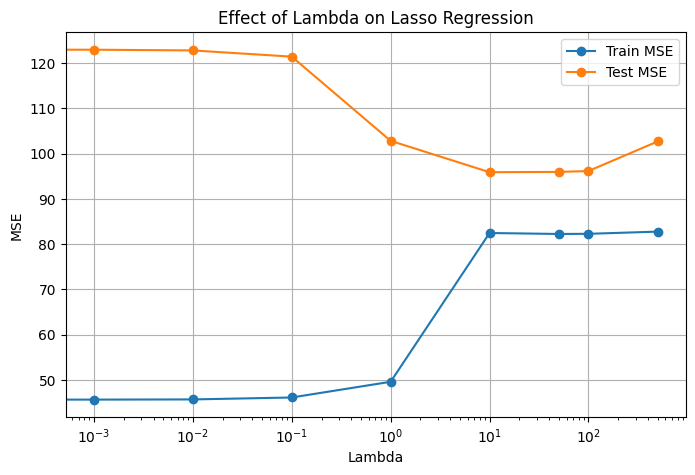

In [233]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    lambda_values,
    train_errors,
    marker="o",
    label="Train MSE"
)

plt.plot(
    lambda_values,
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xscale(
    "log"
)

plt.xlabel(
    "Lambda"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Effect of Lambda on Lasso Regression"
)

plt.legend()
plt.grid()
plt.show()

<h3> Step 10: Checking zero weights for the best λ

In [234]:
best_lambda = 10

best_lasso_model = LassoRegressionGD(
    learning_rate=0.0001,
    epochs=10000,
    lambda_=best_lambda
)

best_lasso_model.fit(
    X_train_poly,
    y_train
)

weights = best_lasso_model.weights

zero_weights = np.sum(
    np.isclose(
        weights,
        0
    )
)

print(
    "Number of zero weights:",
    zero_weights
)

Number of zero weights: 1


In [235]:
zero_weights = np.sum(
    np.isclose(
        weights,
        0
    )
)

print(
    "Number of zero weights:",
    zero_weights
)

Number of zero weights: 1


We implemented Lasso using standard Gradient Descent:

$$ \lambda \text{sign}(w) $$

However, true Lasso presents a problem:

The function:

$$ |w| $$

is not differentiable at zero.

Professional libraries like `scikit-learn` typically employ methods such as:

*Coordinate Descent.*

Because L1 exhibits a specific behavior at zero.</br>
Therefore, the expectation that a simple GD implementation will drive many weights to zero does not always hold true.

In [236]:
threshold = 1e-3

small_weights = np.sum(
    np.abs(weights) < threshold
)

print(
    small_weights
)

2


Almost all polynomial features contain little information.

Ridge usually performs better in such situations.

### Lasso Regression Results

Lasso regularization reduced the gap between training and testing error by penalizing large coefficients.

Compared with ordinary polynomial regression, increasing lambda improved generalization performance.

However, in this Gradient Descent implementation, Lasso did not force many coefficients exactly to zero. This is because standard gradient descent is not the ideal optimization method for the non-differentiable L1 penalty. More advanced solvers such as coordinate descent are commonly used for practical Lasso implementations.


<h3> Step 11: Final Comparisons (3 methods)

1. Linear Regression
2. Ridge Regression
3. Lasso Regression

Settings:

Ridge:</br>
$$ \lambda=1 $$

Lasso:</br>
$$ \lambda=10 $$

In [237]:
linear_model = LinearRegressionGD(
    learning_rate=0.001,
    epochs=10000
)

linear_model.fit(
    X_train_poly,
    y_train
)

y_train_pred_linear = linear_model.predict(
    X_train_poly
)

y_test_pred_linear = linear_model.predict(
    X_test_poly
)

linear_train_mse = mean_squared_error(
    y_train,
    y_train_pred_linear
)

linear_test_mse = mean_squared_error(
    y_test,
    y_test_pred_linear
)

In [238]:
ridge_model = RidgeRegressionGD(
    learning_rate=0.0001,
    epochs=10000,
    lambda_=1
)

ridge_model.fit(
    X_train_poly,
    y_train
)

y_train_pred_ridge = ridge_model.predict(
    X_train_poly
)

y_test_pred_ridge = ridge_model.predict(
    X_test_poly
)

ridge_train_mse = mean_squared_error(
    y_train,
    y_train_pred_ridge
)

ridge_test_mse = mean_squared_error(
    y_test,
    y_test_pred_ridge
)

In [239]:
lasso_model = LassoRegressionGD(
    learning_rate=0.0001,
    epochs=10000,
    lambda_=10
)

lasso_model.fit(
    X_train_poly,
    y_train
)

y_train_pred_lasso = lasso_model.predict(
    X_train_poly
)

y_test_pred_lasso = lasso_model.predict(
    X_test_poly
)

lasso_train_mse = mean_squared_error(
    y_train,
    y_train_pred_lasso
)

lasso_test_mse = mean_squared_error(
    y_test,
    y_test_pred_lasso
)

In [240]:
final_results = pd.DataFrame(
    {
        "Model": [
            "Linear Regression",
            "Ridge Regression (lambda=1)",
            "Lasso Regression (lambda=10)"
        ],

        "Train MSE": [
            linear_train_mse,
            ridge_train_mse,
            lasso_train_mse
        ],

        "Test MSE": [
            linear_test_mse,
            ridge_test_mse,
            lasso_test_mse
        ]
    }
)


final_results

,Model,Train MSE,Test MSE
0,Linear Regression,35.111705,131.644108
1,Ridge Regression (lambda=1),53.944684,81.391085
2,Lasso Regression (lambda=10),82.471307,95.906266


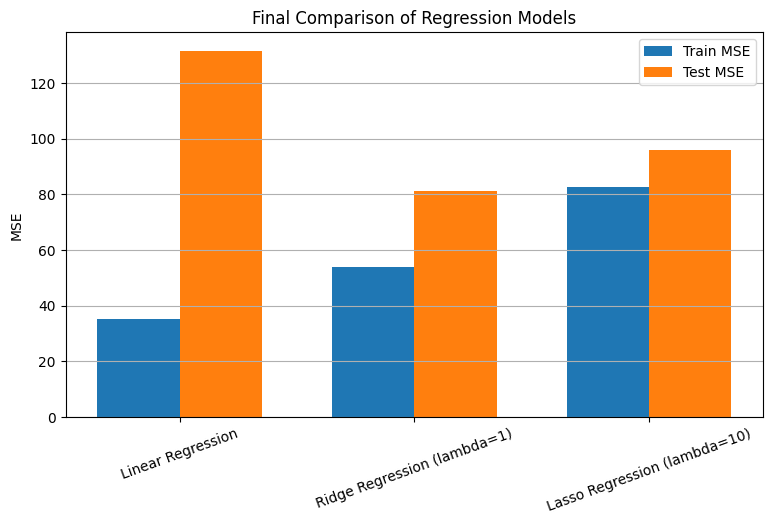

In [241]:
plt.figure(
    figsize=(9,5)
)

x = np.arange(
    len(final_results)
)

width = 0.35

plt.bar(
    x - width/2,
    final_results["Train MSE"],
    width,
    label="Train MSE"
)

plt.bar(
    x + width/2,
    final_results["Test MSE"],
    width,
    label="Test MSE"
)

plt.xticks(
    x,
    final_results["Model"],
    rotation=20
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Final Comparison of Regression Models"
)

plt.legend()

plt.grid(
    axis="y"
)

plt.show()

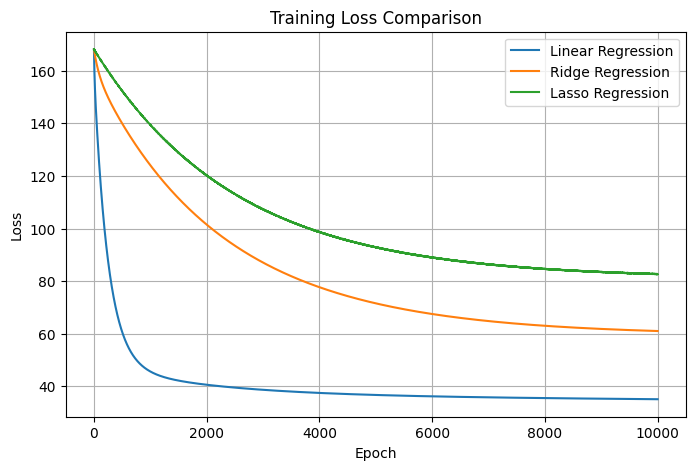

In [242]:
plt.figure(
    figsize=(8,5)
)

plt.plot(
    linear_model.loss_history,
    label="Linear Regression"
)

plt.plot(
    ridge_model.loss_history,
    label="Ridge Regression"
)

plt.plot(
    lasso_model.loss_history,
    label="Lasso Regression"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training Loss Comparison"
)

plt.legend()
plt.grid()
plt.show()

In [243]:
lasso_weights = pd.DataFrame(
    {
        "Feature_Index": np.arange(
            len(lasso_model.weights)
        ),

        "Weight": lasso_model.weights
    }
)


lasso_weights

,Feature_Index,Weight
0,0,0.000000
1,1,-0.001050
2,2,0.000901
3,3,-0.000075
4,4,0.001412
5,5,0.000837
6,6,0.000685
7,7,0.000833
8,8,0.000633
9,9,0.001257
